In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cv2
import os

In [14]:
x_ions = []
with open ('rho_ions.txt') as data:
    for line in data:
        x_ions.append(line.split())
        #x_ions = x_ions.astype(np.float64)
    #print(type(data))
x_ions = np.array(x_ions).astype(np.float64)
#x_ions *= (-1)
x_el = []
with open ('rho_el.txt') as data:
    for line in data:
        x_el.append(line.split())
        #x_ions = x_ions.astype(np.float64)
    #print(type(data))
x_el = np.array(x_el).astype(np.float64)
x_ions *= (-1)


#print(len(x_ions[3]))

In [14]:
print(len(line))
print(len(np.arange(250)))

1191
250


Вращение в поле B

KeyboardInterrupt: 

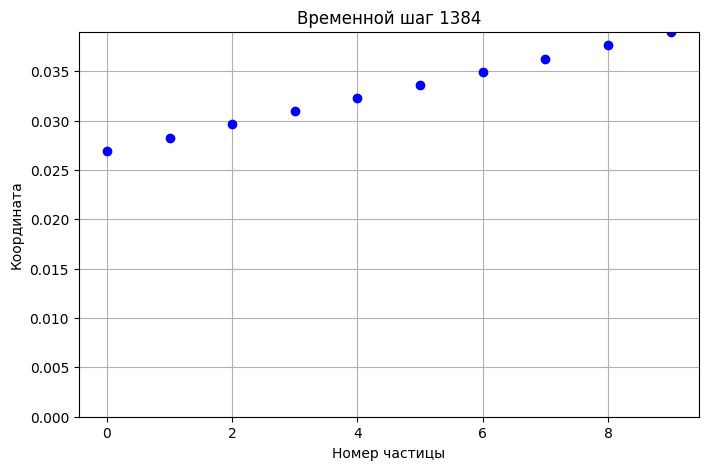

In [27]:
y_max = np.max(x_el)
for i in range(len(x_el)):

    plt.figure(figsize=(8, 5))
    plt.ylim(0, y_max)   
    plt.plot(range(len(x_el[0])), x_el[i], marker='o', linestyle='', color='b')
    plt.xlabel("Номер частицы")
    plt.ylabel("Координата")
    plt.title(f"Временной шаг {i}")
    plt.grid()
    
    # Сохраняем изображение
    plt.savefig(f"X_{i}.png")
    plt.close()

Построение плотности

In [8]:
x_ions = []
with open ('rho_ions.txt') as data:
    for line in data:
        x_ions.append(line.split())
        #x_ions = x_ions.astype(np.float64)
    #print(type(data))
x_ions = np.array(x_ions).astype(np.float64)
#x_ions *= (-1)
x_el = []
with open ('rho_el.txt') as data:
    for line in data:
        x_el.append(line.split())
        #x_ions = x_ions.astype(np.float64)
    #print(type(data))
x_el = np.array(x_el).astype(np.float64)
x_ions *= (-1)

Общая концентрация

KeyboardInterrupt: 

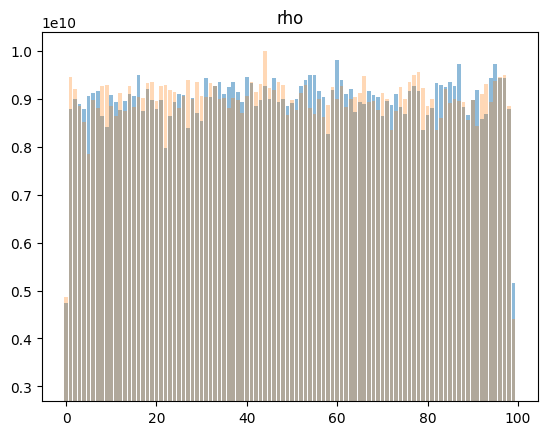

In [9]:

i = 0
for i in range(len(x_ions)):
    plt.figure()
    plt.title('rho')
    plt.ylim(min(x_el.min(), x_ions.min()), max(x_el.max(), x_ions.max()))
    plt.bar(np.arange(len(x_el[0])), x_el[i], alpha = 0.5)
    plt.bar(np.arange(len(x_el[0])), x_ions[i], alpha = 0.3)
    plt.savefig(f'rho_{i}')
    plt.close()
    #i += 1
    #break

In [14]:
i = 0
for i in range(len(x_ions)):
    plt.figure()
    plt.title('rho_ions')
    plt.ylim(x_ions.min(), x_ions.max())
    #plt.bar(np.arange(len(x_el[0])), x_el[i], alpha = 0.5)
    plt.bar(np.arange(len(x_el[0])), x_ions[i], alpha = 0.3)
    plt.savefig(f'rho_{i}')
    plt.close()
    #i += 1
    #break

In [17]:
i = 0
for i in range(len(x_ions)):
    plt.figure()
    plt.title('rho_el')
    plt.ylim(x_el.min(), x_el.max())
    plt.bar(np.arange(len(x_el[0])), x_el[i], alpha = 0.5)
    #plt.bar(np.arange(len(x_el[0])), x_ions[i], alpha = 0.3)
    plt.savefig(f'rho_el_{i}')
    plt.close()
    #i += 1
    #break

Нахождение потенциала

In [4]:
fi = []
with open ('fi.txt') as data:
    for line in data:
        fi.append(line.split())
        #x_ions = x_ions.astype(np.float64)
    #print(type(data))
fi = np.array(fi).astype(np.float64)

KeyboardInterrupt: 

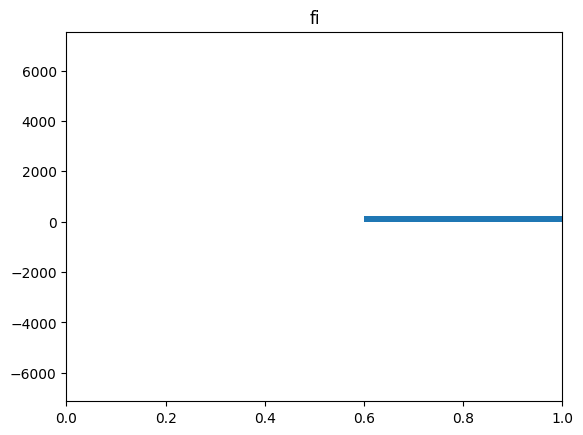

In [5]:
for i in range(len(fi)):
    plt.figure()
    plt.title('fi')
    plt.ylim(fi.min(), fi.max())
    plt.bar(np.arange(len(fi[0])), fi[i])
    #plt.bar(np.arange(len(x_el[0])), x_ions[i], alpha = 0.3)
    plt.savefig(f'fi_{i}')
    plt.close()

In [19]:
# Параметры
image_folder = '.'  # Папка с изображениями (текущая папка)
output_video = '!_электроны.avi'  # Имя выходного видеофайла
fps = 5  # Частота кадров (можно настроить по своему усмотрению)

# Список файлов изображений
image_files = [f for f in os.listdir(image_folder) if f.startswith('rho_el_') and f.endswith('.png')]

# Сортировка файлов по номеру
image_files.sort(key=lambda f: int(f.split('_')[-1].split('.')[0]))

# Прочитаем первое изображение для определения размера
first_image = cv2.imread(os.path.join(image_folder, image_files[0]))
height, width, _ = first_image.shape

# Создаем объект для записи видео
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Кодек для AVI
video_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# Добавляем изображения в видео
for image_file in image_files:
    image_path = os.path.join(image_folder, image_file)
    image = cv2.imread(image_path)
    video_writer.write(image)

# Освобождаем ресурсы
video_writer.release()

print(f"Видео успешно создано: {output_video}")

Видео успешно создано: !_электроны.avi
